In [17]:

# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [18]:
data = {
    'job_title_short': ['Data Analyst', 'Data Scientist', 'Data Engineer'],
    'job_skills': [['excel', 'sql', 'python'], ['python', 'r'], ['aws', 'python', 'airflow']]
}

df_skills = pd.DataFrame(data)

df_skills

,job_title_short,job_skills
0,Data Analyst,"[excel, sql, python]"
1,Data Scientist,"[python, r]"
2,Data Engineer,"[aws, python, airflow]"


In [19]:
df_skills.value_counts('job_skills')  #cant  count val in list so use explode

TypeError: unhashable type: 'list'

In [20]:
df_exploded = df_skills.explode('job_skills')
df_exploded

,job_title_short,job_skills
0,Data Analyst,excel
0,Data Analyst,sql
0,Data Analyst,python
1,Data Scientist,python
1,Data Scientist,r
2,Data Engineer,aws
2,Data Engineer,python
2,Data Engineer,airflow


In [21]:
df_exploded.value_counts('job_skills')

job_skills
python     3
airflow    1
aws        1
excel      1
r          1
sql        1
Name: count, dtype: int64

<Axes: xlabel='job_skills'>

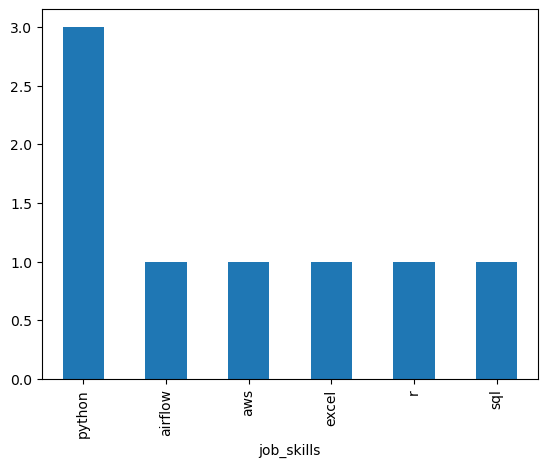

In [ ]:
df_exploded.value_counts('job_skills').plot(kind='bar')

In [22]:
type(df_skills['job_skills'])

pandas.core.series.Series

In [ ]:
type(df_skills['job_skills'][0])

list

In [ ]:
type('job_skills')

str

In [ ]:
# Convert string representation to actual list, checking for NaN values first

df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

df[['job_title_short', 'job_skills']].head(5)

,job_title_short,job_skills
0,Senior Data Engineer,None
1,Data Analyst,"[r, python, sql, nosql, power bi, tableau]"
2,Data Engineer,"[python, sql, c#, azure, airflow, dax, docker,..."
3,Data Engineer,"[python, c++, java, matlab, aws, tensorflow, k..."
4,Data Engineer,"[bash, python, oracle, aws, ansible, puppet, j..."


In [ ]:
df_exploded = df.explode('job_skills')
df_exploded

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,r,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,python,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,sql,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,nosql,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,None,NaN,NaN,Capital One,kafka,"{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,None,NaN,NaN,Capital One,kubernetes,"{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,None,NaN,NaN,Capital One,docker,"{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."
785740,Software Engineer,AWS System Analyst,India,melalui Trigyn,Pekerjaan tetap,False,India,2023-03-13 06:16:31,False,False,India,None,NaN,NaN,Trigyn,aws,"{'cloud': ['aws'], 'other': ['flow']}"


<Axes: xlabel='job_skills'>

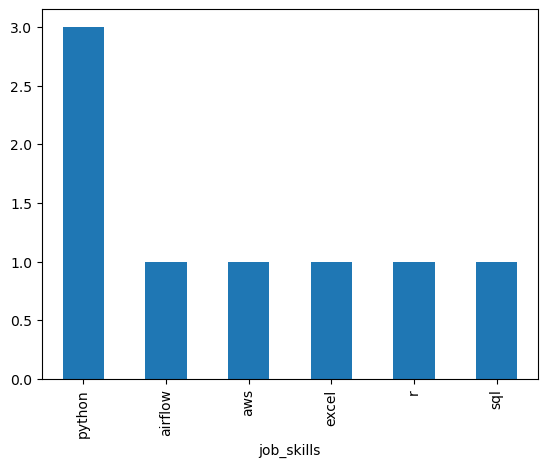

In [23]:
df_exploded.value_counts('job_skills').plot(kind='bar')

<Axes: xlabel='job_skills'>

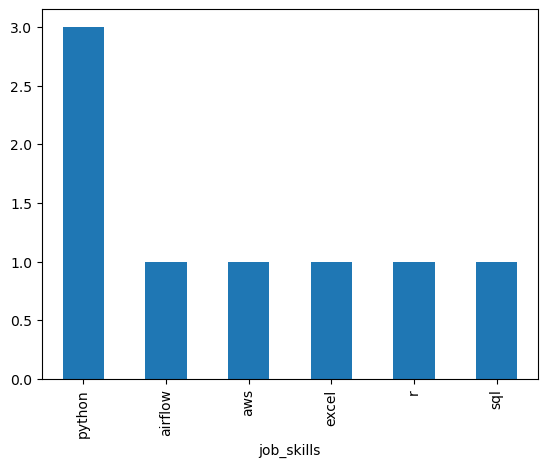

In [24]:
df_exploded.value_counts('job_skills').head(10).plot(kind='bar')

. calculate the skill count for each job

In [25]:
skill_count = df_exploded.groupby(['job_title_short', 'job_skills']).size()
skill_count

job_title_short  job_skills
Data Analyst     excel         1
                 python        1
                 sql           1
Data Engineer    airflow       1
                 aws           1
                 python        1
Data Scientist   python        1
                 r             1
dtype: int64

In [26]:
df_exploded.groupby(['job_title_short', 'job_skills']).value_counts()

job_title_short  job_skills
Data Analyst     excel         1
                 python        1
                 sql           1
Data Engineer    airflow       1
                 aws           1
                 python        1
Data Scientist   python        1
                 r             1
Name: count, dtype: int64

In [27]:
type(skill_count)

pandas.core.series.Series

. We'll reset_index to transform skills_count from a Series to a DataFrame.
. The index contains the skill names.
The values contain the counts.

This is a Series, not a DataFrame.

In [29]:
df_skills_count = skill_count.reset_index()
df_skills_count

,job_title_short,job_skills,0
0,Data Analyst,excel,1
1,Data Analyst,python,1
2,Data Analyst,sql,1
3,Data Engineer,airflow,1
4,Data Engineer,aws,1
5,Data Engineer,python,1
6,Data Scientist,python,1
7,Data Scientist,r,1


In [30]:
df_skills_count = skill_count.reset_index(name='skill_count')
df_skills_count

,job_title_short,job_skills,skill_count
0,Data Analyst,excel,1
1,Data Analyst,python,1
2,Data Analyst,sql,1
3,Data Engineer,airflow,1
4,Data Engineer,aws,1
5,Data Engineer,python,1
6,Data Scientist,python,1
7,Data Scientist,r,1


In [32]:
#sort in desc

df_skills_count.sort_values(by='skill_count', ascending=False,  inplace=True)

df_skills_count

,job_title_short,job_skills,skill_count
0,Data Analyst,excel,1
1,Data Analyst,python,1
2,Data Analyst,sql,1
3,Data Engineer,airflow,1
4,Data Engineer,aws,1
5,Data Engineer,python,1
6,Data Scientist,python,1
7,Data Scientist,r,1


top 10 val for data analyst

In [40]:
job_title = 'Data Analyst'  #dataset is wrong so there are only 7 val in that

df_skill_final = df_skills_count[df_skills_count['job_title_short']=='job_title'].head(2)
df_skill_final

,job_title_short,job_skills,skill_count


IndexError: index 0 is out of bounds for axis 0 with size 0

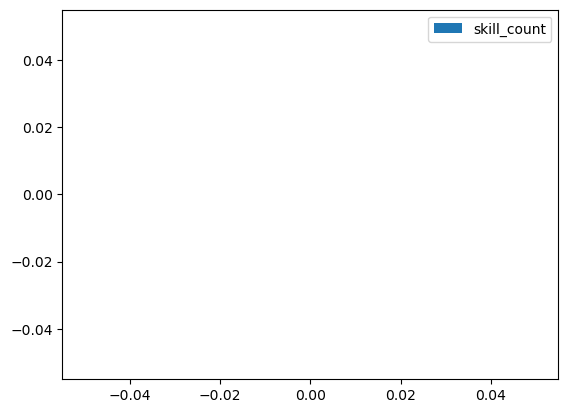

In [35]:
df_skill_final.plot(kind='barh', x='job_skills', y='skill_count')

IndexError: index 0 is out of bounds for axis 0 with size 0

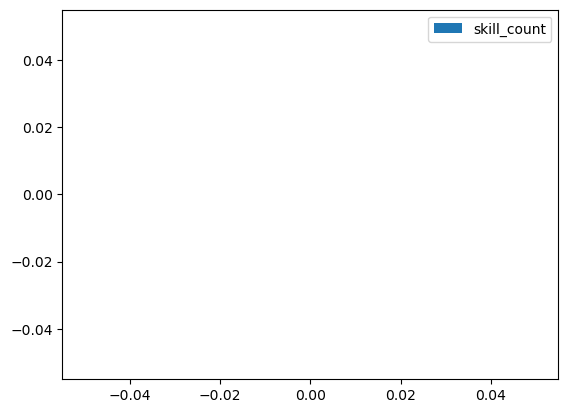

In [36]:
df_skill_final.plot(kind='barh', x='job_skills', y='skill_count')
plt.gca().invert_yaxis()